# GNN v3 Results Analysis

Visualises `submission_gnn_v3_local.csv` and `oof_gnn_v3_local.csv`.

Comparisons: Baseline → GNN v2 → GNN v3

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os

import config
from data_utils import load_ground_truth, compute_wmae, compute_wmae_per_pert

config.make_dirs()
FIGURES = config.FIGURES_DIR
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

de_matrix, weight_matrix, gene_order, pert_order = load_ground_truth()
gene_to_idx = {g: i for i, g in enumerate(gene_order)}
pert_to_idx = {p: i for i, p in enumerate(pert_order)}
print('Ground truth loaded:', de_matrix.shape)

Ground truth: 80 perturbations × 5127 genes
Ground truth loaded: (80, 5127)


## 1. Load OOF predictions (v2 + v3)

In [2]:
def load_oof(fname):
    """Load OOF CSV and align rows to pert_order. Returns (n_perts, n_genes) array."""
    path = os.path.join(config.SUBMISSIONS_DIR, fname)
    if not os.path.exists(path):
        print(f'  NOT FOUND: {path}')
        return None
    df = pd.read_csv(path).set_index('pert_id')
    # Keep only gene columns that are in gene_order
    df = df[[g for g in gene_order if g in df.columns]]
    arr = np.zeros((len(pert_order), len(gene_order)), dtype=np.float32)
    for i, p in enumerate(pert_order):
        if p in df.index:
            arr[i] = df.loc[p].values
    return arr

oof_v2 = load_oof('oof_gnn_v2_local.csv')
oof_v3 = load_oof('oof_gnn_v3_local.csv')

# Baseline = mean DE vector broadcast to all perturbations
mean_de = de_matrix.mean(axis=0, keepdims=True)
oof_base = np.tile(mean_de, (len(pert_order), 1))

baseline_wmae = compute_wmae(oof_base, de_matrix, weight_matrix)
v2_wmae       = compute_wmae(oof_v2, de_matrix, weight_matrix) if oof_v2 is not None else None
v3_wmae       = compute_wmae(oof_v3, de_matrix, weight_matrix) if oof_v3 is not None else None

print(f'Baseline WMAE : {baseline_wmae:.4f}')
if v2_wmae: print(f'GNN v2 OOF    : {v2_wmae:.4f}  (Δ {(baseline_wmae-v2_wmae)/baseline_wmae*100:+.1f}%)')
if v3_wmae: print(f'GNN v3 OOF    : {v3_wmae:.4f}  (Δ {(baseline_wmae-v3_wmae)/baseline_wmae*100:+.1f}%)')
if v2_wmae and v3_wmae:
    print(f'v3 vs v2      : Δ {(v2_wmae-v3_wmae)/v2_wmae*100:+.1f}%')

Baseline WMAE : 0.1268
GNN v2 OOF    : 0.1167  (Δ +8.0%)
GNN v3 OOF    : 0.1164  (Δ +8.2%)
v3 vs v2      : Δ +0.2%


## 2. Overall WMAE bar chart

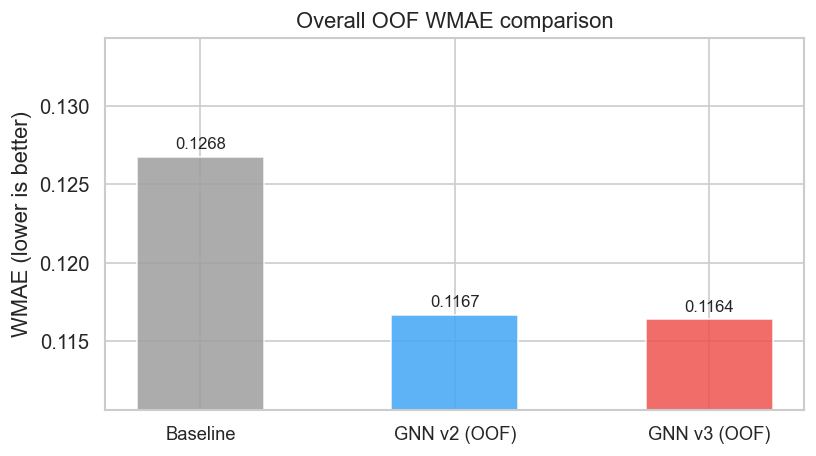

In [3]:
labels  = ['Baseline', 'GNN v2 (OOF)', 'GNN v3 (OOF)']
wmaes   = [baseline_wmae, v2_wmae, v3_wmae]
colors  = ['#9E9E9E', '#42A5F5', '#EF5350']
valid   = [(l, w, c) for l, w, c in zip(labels, wmaes, colors) if w is not None]

fig, ax = plt.subplots(figsize=(7, 4))
xs = range(len(valid))
bars = ax.bar(xs, [w for _, w, _ in valid], color=[c for _, _, c in valid],
              width=0.5, alpha=0.85, edgecolor='white')

ax.set_xticks(list(xs))
ax.set_xticklabels([l for l, _, _ in valid], fontsize=11)
ax.set_ylabel('WMAE (lower is better)')
ax.set_title('Overall OOF WMAE comparison')
ax.set_ylim(min(w for _, w, _ in valid) * 0.95, baseline_wmae * 1.06)

for bar, (_, w, _) in zip(bars, valid):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0003,
            f'{w:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES, '13_v3_overall_wmae.png'), bbox_inches='tight')
plt.show()

## 3. Per-perturbation WMAE: Baseline vs v3 (sorted by v3 WMAE)

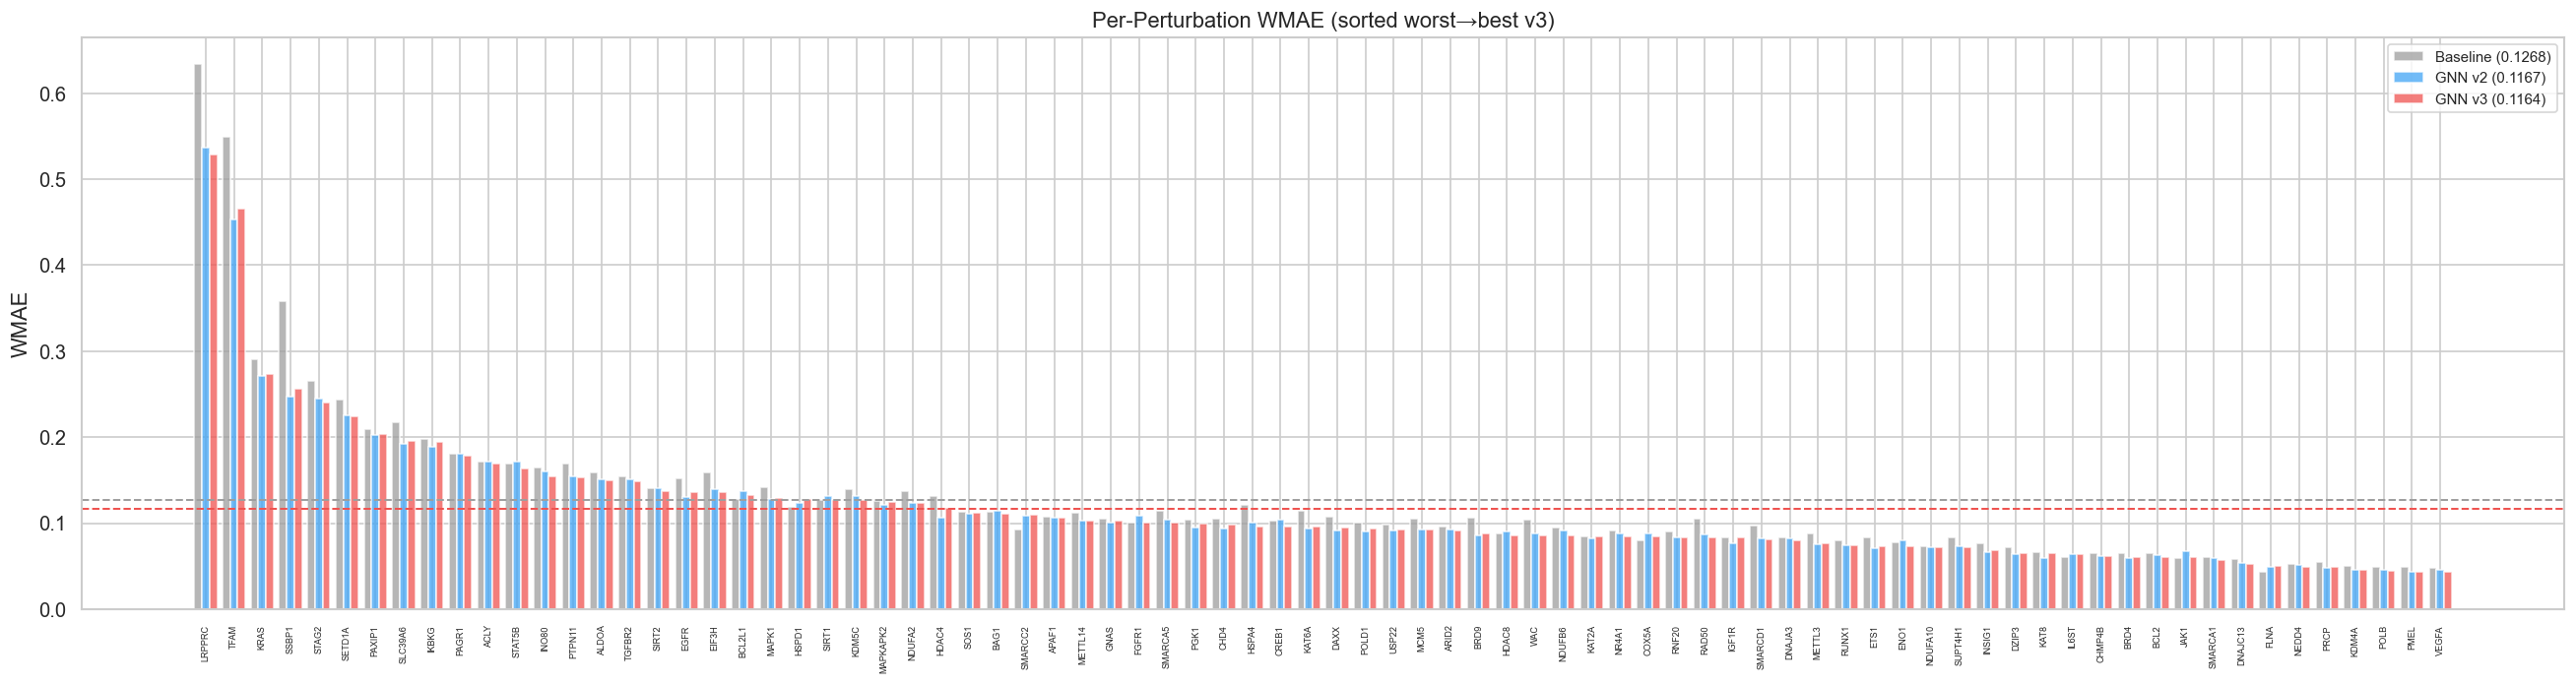

v3 improved over baseline : 70/80
v3 improved over v2       : 42/80


In [4]:
if oof_v3 is not None:
    base_pp = compute_wmae_per_pert(oof_base, de_matrix, weight_matrix)
    v3_pp   = compute_wmae_per_pert(oof_v3,   de_matrix, weight_matrix)
    v2_pp   = compute_wmae_per_pert(oof_v2,   de_matrix, weight_matrix) if oof_v2 is not None else None

    sort_idx = np.argsort(v3_pp)[::-1]  # worst first
    n = len(pert_order)
    x = np.arange(n)
    w = 0.27

    fig, ax = plt.subplots(figsize=(22, 6))
    ax.bar(x - w,   base_pp[sort_idx], w, label=f'Baseline ({baseline_wmae:.4f})',
           color='#9E9E9E', alpha=0.75)
    if v2_pp is not None:
        ax.bar(x,    v2_pp[sort_idx], w, label=f'GNN v2 ({v2_wmae:.4f})',
               color='#42A5F5', alpha=0.75)
    ax.bar(x + w,   v3_pp[sort_idx], w, label=f'GNN v3 ({v3_wmae:.4f})',
           color='#EF5350', alpha=0.75)

    ax.axhline(v3_wmae,       color='#EF5350', linestyle='--', linewidth=1.2)
    ax.axhline(baseline_wmae, color='#9E9E9E', linestyle='--', linewidth=1.2)

    ax.set_xticks(x)
    ax.set_xticklabels([pert_order[i] for i in sort_idx], rotation=90, fontsize=5.5)
    ax.set_ylabel('WMAE')
    ax.set_title('Per-Perturbation WMAE (sorted worst→best v3)')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES, '14_v3_per_pert_wmae.png'), bbox_inches='tight')
    plt.show()

    improved_over_base = (v3_pp < base_pp).sum()
    print(f'v3 improved over baseline : {improved_over_base}/{n}')
    if v2_pp is not None:
        improved_over_v2 = (v3_pp < v2_pp).sum()
        print(f'v3 improved over v2       : {improved_over_v2}/{n}')

## 4. Scatter: v3 WMAE vs baseline WMAE (per perturbation)

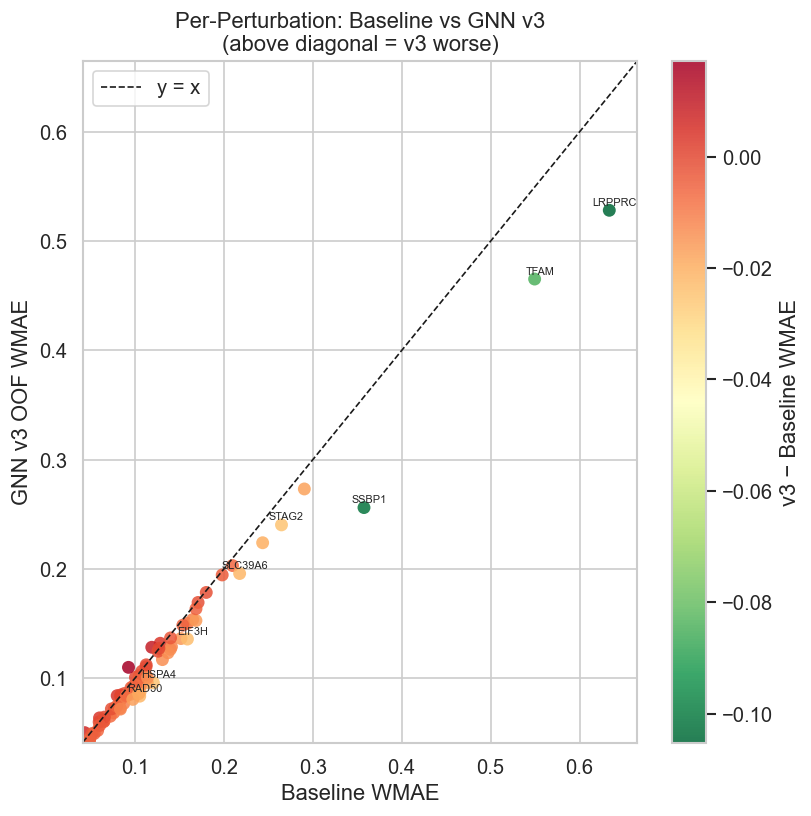

In [5]:
if oof_v3 is not None:
    fig, ax = plt.subplots(figsize=(7, 7))
    delta = v3_pp - base_pp   # negative = improvement
    sc = ax.scatter(base_pp, v3_pp, c=delta, cmap='RdYlGn_r',
                    s=60, alpha=0.85, edgecolors='none')
    plt.colorbar(sc, ax=ax, label='v3 − Baseline WMAE')

    lim_max = max(base_pp.max(), v3_pp.max()) * 1.05
    lim_min = min(base_pp.min(), v3_pp.min()) * 0.95
    ax.plot([lim_min, lim_max], [lim_min, lim_max], 'k--', linewidth=1, label='y = x')
    ax.set_xlim(lim_min, lim_max)
    ax.set_ylim(lim_min, lim_max)
    ax.set_xlabel('Baseline WMAE')
    ax.set_ylabel('GNN v3 OOF WMAE')
    ax.set_title('Per-Perturbation: Baseline vs GNN v3\n(above diagonal = v3 worse)')
    ax.legend()

    # Label outliers
    threshold = np.percentile(np.abs(delta), 90)
    for i, (bv, vv, name) in enumerate(zip(base_pp, v3_pp, pert_order)):
        if abs(delta[i]) > threshold:
            ax.annotate(name, (bv, vv), fontsize=6.5, ha='center',
                        xytext=(3, 3), textcoords='offset points')

    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES, '15_v3_scatter_base_vs_v3.png'), bbox_inches='tight')
    plt.show()

## 5. Predicted vs GT: 6 example perturbations

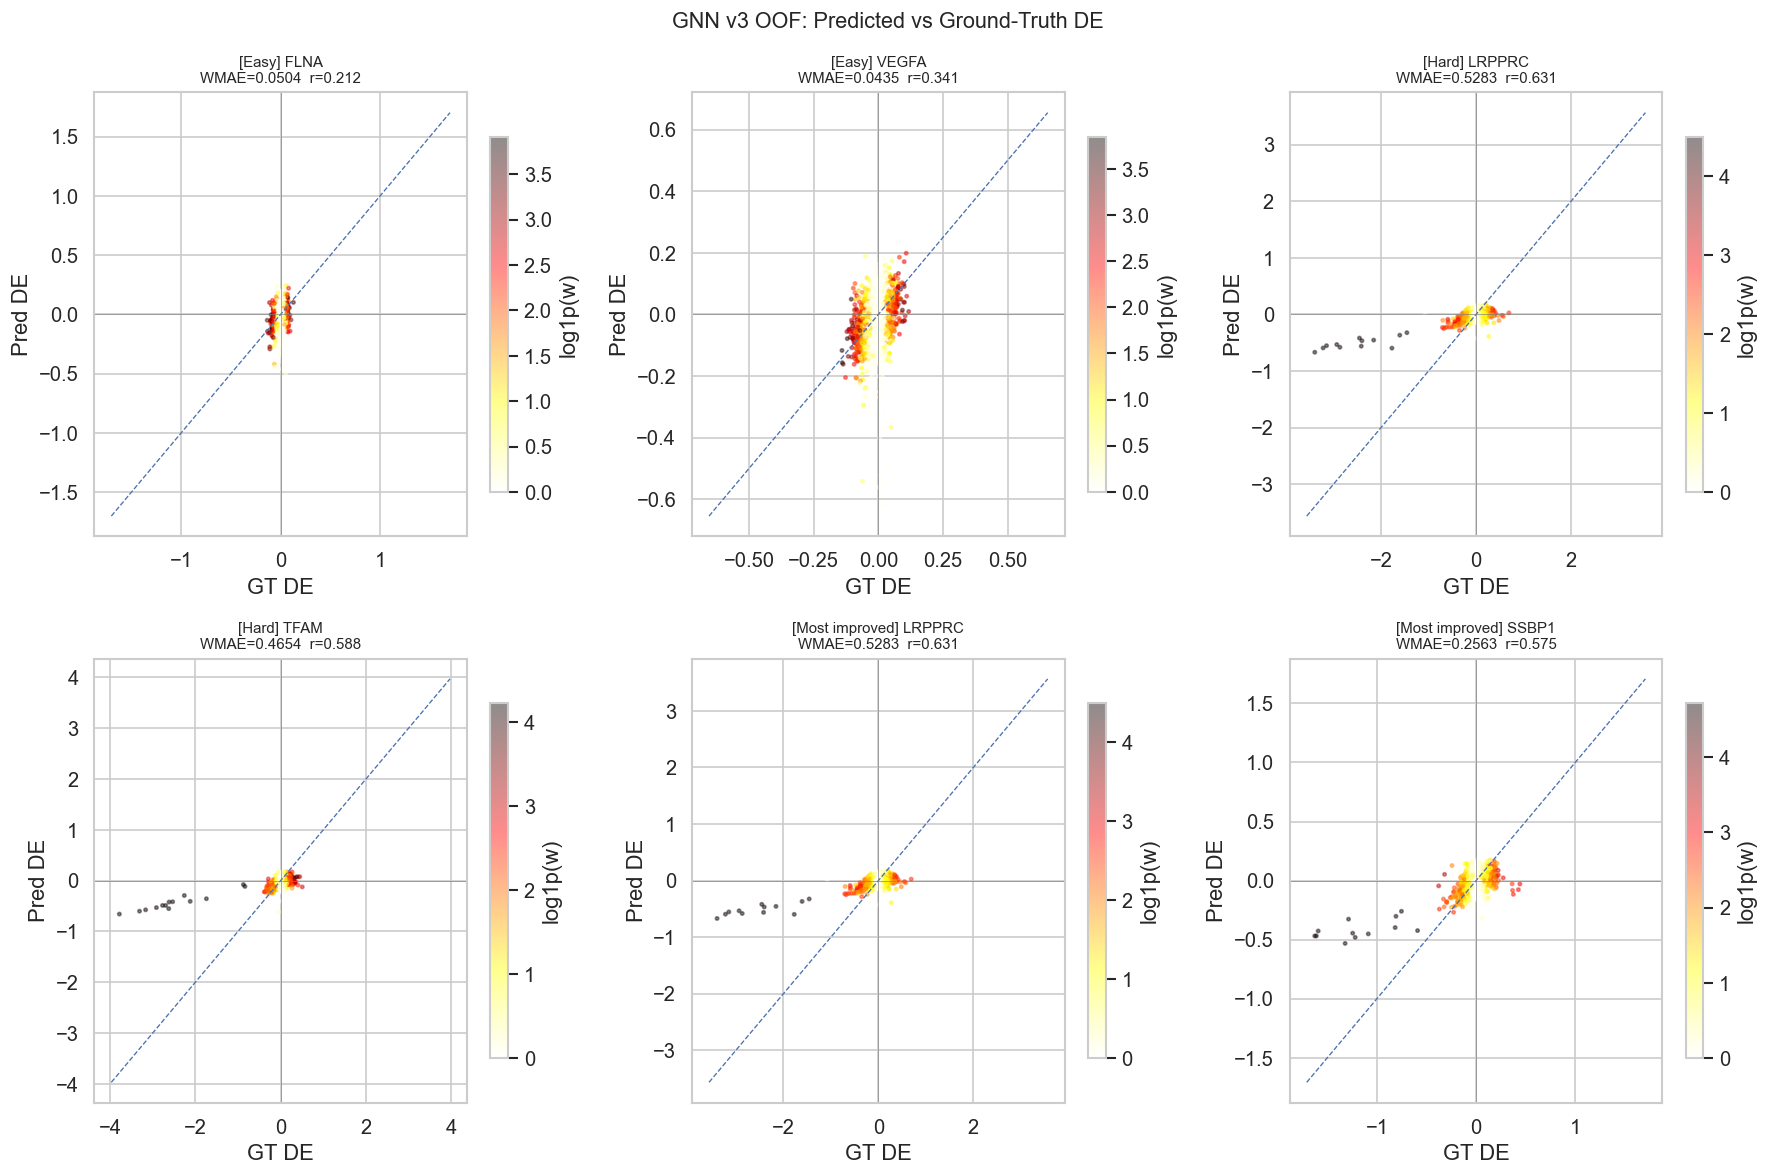

In [6]:
if oof_v3 is not None:
    gt_meta = pd.read_csv(config.GT_PATH)[['pert_id','baseline_wmae']]
    # Pick 2 easy, 2 hard, 2 most improved by v3
    easy2 = gt_meta.nsmallest(2, 'baseline_wmae')['pert_id'].tolist()
    hard2 = gt_meta.nlargest(2, 'baseline_wmae')['pert_id'].tolist()
    delta_df = pd.DataFrame({'pert_id': pert_order, 'delta': v3_pp - base_pp})
    most_improved2 = delta_df.nsmallest(2, 'delta')['pert_id'].tolist()
    examples = easy2 + hard2 + most_improved2
    titles   = ['Easy','Easy','Hard','Hard','Most improved','Most improved']

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    for ax, gene, tag in zip(axes, examples, titles):
        if gene not in pert_to_idx:
            ax.set_visible(False)
            continue
        i = pert_to_idx[gene]
        gt   = de_matrix[i]
        pred = oof_v3[i]
        w    = weight_matrix[i]

        sc = ax.scatter(gt, pred, c=np.log1p(w), s=4, alpha=0.45,
                        cmap='hot_r', rasterized=True)
        plt.colorbar(sc, ax=ax, label='log1p(w)', shrink=0.8)

        lim = max(np.abs(gt).max(), np.abs(pred).max()) * 1.05
        ax.plot([-lim, lim], [-lim, lim], 'b--', linewidth=0.8)
        ax.axhline(0, color='gray', linewidth=0.4)
        ax.axvline(0, color='gray', linewidth=0.4)

        wmae = compute_wmae(pred[None], gt[None], w[None])
        corr = np.corrcoef(gt, pred)[0, 1]
        ax.set_title(f'[{tag}] {gene}\nWMAE={wmae:.4f}  r={corr:.3f}', fontsize=9)
        ax.set_xlabel('GT DE')
        ax.set_ylabel('Pred DE')

    plt.suptitle('GNN v3 OOF: Predicted vs Ground-Truth DE', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES, '16_v3_pred_vs_gt.png'), bbox_inches='tight')
    plt.show()

## 6. Test submission: distribution + per-perturbation prediction magnitude

v2 test:  mean|pred|=0.0309  std=0.0511
v3 test:  mean|pred|=0.0308  std=0.0501


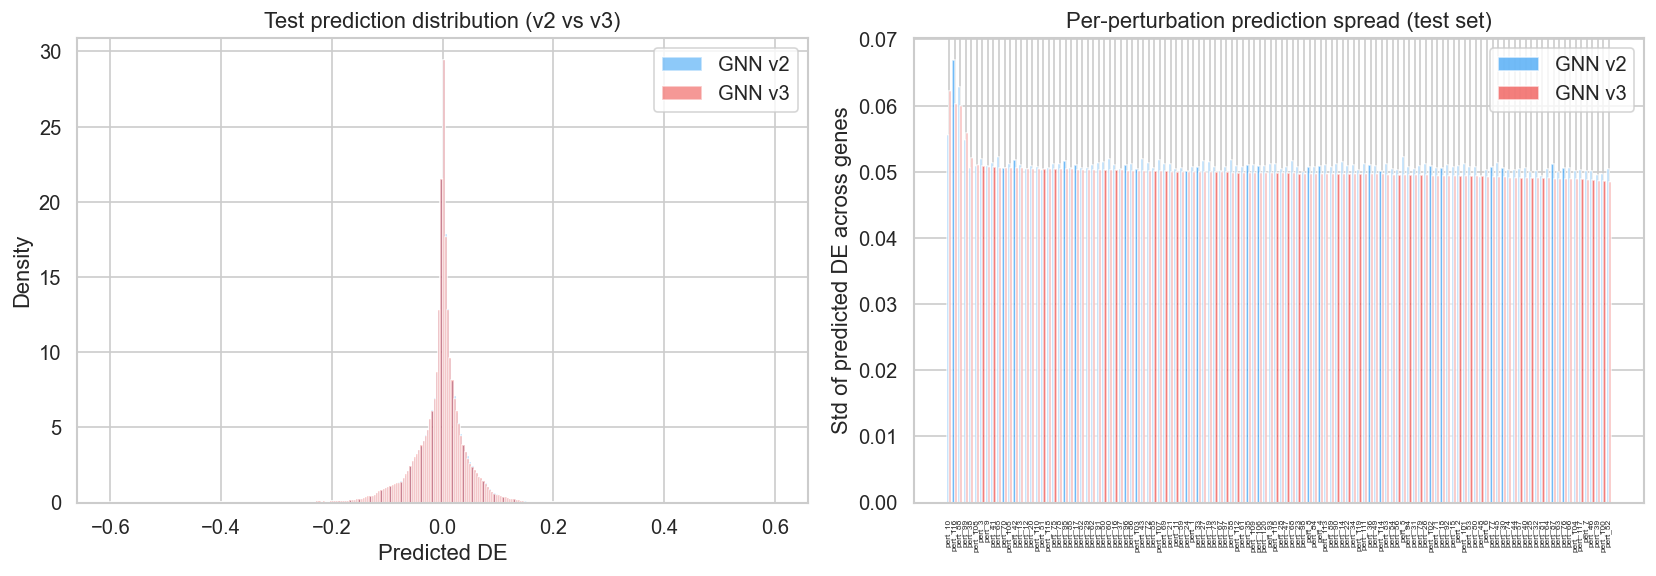

In [7]:
sub_v2 = pd.read_csv(os.path.join(config.SUBMISSIONS_DIR, 'submission_gnn_v2_local.csv'))
sub_v3 = pd.read_csv(os.path.join(config.SUBMISSIONS_DIR, 'submission_gnn_v3_local.csv'))
gene_cols = [c for c in sub_v3.columns if c != 'pert_id']

v2_vals = sub_v2[gene_cols].values
v3_vals = sub_v3[gene_cols].values

print('v2 test:  mean|pred|={:.4f}  std={:.4f}'.format(np.abs(v2_vals).mean(), v2_vals.std()))
print('v3 test:  mean|pred|={:.4f}  std={:.4f}'.format(np.abs(v3_vals).mean(), v3_vals.std()))

# ── Distribution plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(v2_vals.flatten(), bins=300, range=(-0.6, 0.6), alpha=0.6,
        label='GNN v2', color='#42A5F5', density=True)
ax.hist(v3_vals.flatten(), bins=300, range=(-0.6, 0.6), alpha=0.6,
        label='GNN v3', color='#EF5350', density=True)
ax.set_xlabel('Predicted DE')
ax.set_ylabel('Density')
ax.set_title('Test prediction distribution (v2 vs v3)')
ax.legend()

# ── Per-perturbation std ──
ax = axes[1]
v2_std_pp = v2_vals.std(axis=1)
v3_std_pp = v3_vals.std(axis=1)
perts = sub_v3['pert_id'].values
sort_idx = np.argsort(v3_std_pp)[::-1]
x = np.arange(len(perts))
ax.bar(x - 0.2, v2_std_pp[sort_idx], 0.4, label='GNN v2', color='#42A5F5', alpha=0.75)
ax.bar(x + 0.2, v3_std_pp[sort_idx], 0.4, label='GNN v3', color='#EF5350', alpha=0.75)
ax.set_xticks(x)
ax.set_xticklabels(perts[sort_idx], rotation=90, fontsize=5)
ax.set_ylabel('Std of predicted DE across genes')
ax.set_title('Per-perturbation prediction spread (test set)')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES, '17_v3_test_distribution.png'), bbox_inches='tight')
plt.show()

## 7. v2 vs v3 prediction difference (test set heatmap)

Max |diff|: 0.6207  Mean |diff|: 0.0050


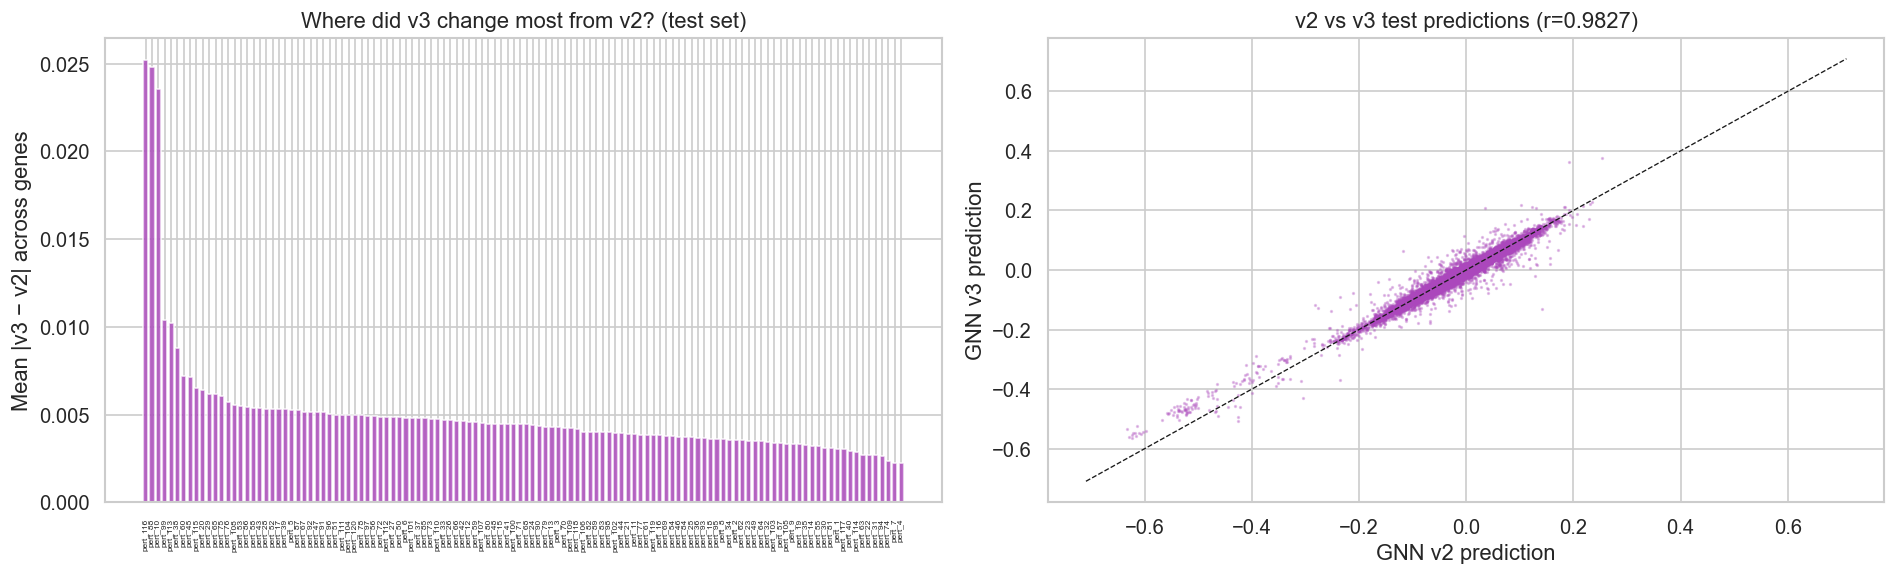

In [8]:
diff = v3_vals - v2_vals   # (120, 5127)
print(f'Max |diff|: {np.abs(diff).max():.4f}  Mean |diff|: {np.abs(diff).mean():.4f}')

# Summarise per perturbation
diff_mean_abs = np.abs(diff).mean(axis=1)
sort_idx = np.argsort(diff_mean_abs)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart of mean |diff| per pert
ax = axes[0]
ax.bar(range(len(perts)), diff_mean_abs[sort_idx], color='#AB47BC', alpha=0.8)
ax.set_xticks(range(len(perts)))
ax.set_xticklabels(perts[sort_idx], rotation=90, fontsize=5)
ax.set_ylabel('Mean |v3 − v2| across genes')
ax.set_title('Where did v3 change most from v2? (test set)')

# Scatter v2 vs v3 flat
ax = axes[1]
sample = np.random.default_rng(42).choice(v2_vals.size, size=50_000, replace=False)
ax.scatter(v2_vals.flatten()[sample], v3_vals.flatten()[sample],
           s=1, alpha=0.3, color='#AB47BC', rasterized=True)
lim = max(np.abs(v2_vals).max(), np.abs(v3_vals).max()) * 1.02
ax.plot([-lim, lim], [-lim, lim], 'k--', linewidth=0.8)
ax.set_xlabel('GNN v2 prediction')
ax.set_ylabel('GNN v3 prediction')
r = np.corrcoef(v2_vals.flatten()[sample], v3_vals.flatten()[sample])[0, 1]
ax.set_title(f'v2 vs v3 test predictions (r={r:.4f})')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES, '18_v3_diff_v2.png'), bbox_inches='tight')
plt.show()

## Summary

In [9]:
print('=' * 55)
print('GNN v3 RESULT SUMMARY')
print('=' * 55)
print(f'Baseline WMAE  : {baseline_wmae:.4f}')
if v2_wmae: print(f'GNN v2 OOF     : {v2_wmae:.4f}  ({(baseline_wmae-v2_wmae)/baseline_wmae*100:+.2f}% vs baseline)')
if v3_wmae: print(f'GNN v3 OOF     : {v3_wmae:.4f}  ({(baseline_wmae-v3_wmae)/baseline_wmae*100:+.2f}% vs baseline)')
if v2_wmae and v3_wmae:
    print(f'v3 vs v2       : {(v2_wmae-v3_wmae)/v2_wmae*100:+.2f}%')
print()
print('Figures saved:')
for fn in sorted(f for f in os.listdir(FIGURES) if f.startswith('1')):
    print(f'  {fn}')

GNN v3 RESULT SUMMARY
Baseline WMAE  : 0.1268
GNN v2 OOF     : 0.1167  (+7.96% vs baseline)
GNN v3 OOF     : 0.1164  (+8.18% vs baseline)
v3 vs v2       : +0.24%

Figures saved:
  11_submission_distributions.png
  13_v3_overall_wmae.png
  14_v3_per_pert_wmae.png
  15_v3_scatter_base_vs_v3.png
  16_v3_pred_vs_gt.png
  17_v3_test_distribution.png
  18_v3_diff_v2.png
